In [1]:
import numpy as np
import pandas as pd

In [2]:
fold0 = pd.read_csv(f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/alpha_genome_validation/ctct_suppressing/fold0_alphagenome_3sineb2_results.tsv", sep="\t")

fold0["fold"] = [0 for i in range(len(fold0))]

In [3]:
fold1 = pd.read_csv(f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/alpha_genome_validation/ctct_suppressing/fold1_alphagenome_3sineb2_results.tsv", sep="\t")

fold1["fold"] = [1 for i in range(len(fold1))]

In [4]:
fold2 = pd.read_csv(f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/alpha_genome_validation/ctct_suppressing/fold2_alphagenome_3sineb2_results.tsv", sep="\t")

fold2["fold"] = [2 for i in range(len(fold2))]

In [5]:
df = pd.concat([fold0, fold1, fold2], ignore_index=True)

In [6]:
df.columns

Index(['chrom', 'fold', 'PearsonR', 'centered_start', 'centered_end',
       'centered_flat_start', 'centered_flat_end', 'active_fraction',
       'neutral_fraction', 'repressive_fraction', 'alpha_og_urq',
       'alpha_ed_urq', 'alpha_urq_diff', 'alpha_sineB2', 'alpha_sineB2_diff'],
      dtype='object')

In [7]:
print("boundary, before optimization: ", df["alpha_og_urq"].mean())
print("after suppression: ", df["alpha_ed_urq"].mean())
print("initial sequence, 3 SINE B2s inserted: ", df["alpha_sineB2"].mean())

boundary, before optimization:  -0.07506990643536585
after suppression:  -0.03273137218292683
initial sequence, 3 SINE B2s inserted:  -0.07090135342292682


/tmp/SLURM_2707390/ipykernel_1504619/4080729495.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Condition', y='Insulation Score (URQ)', data=df_long,


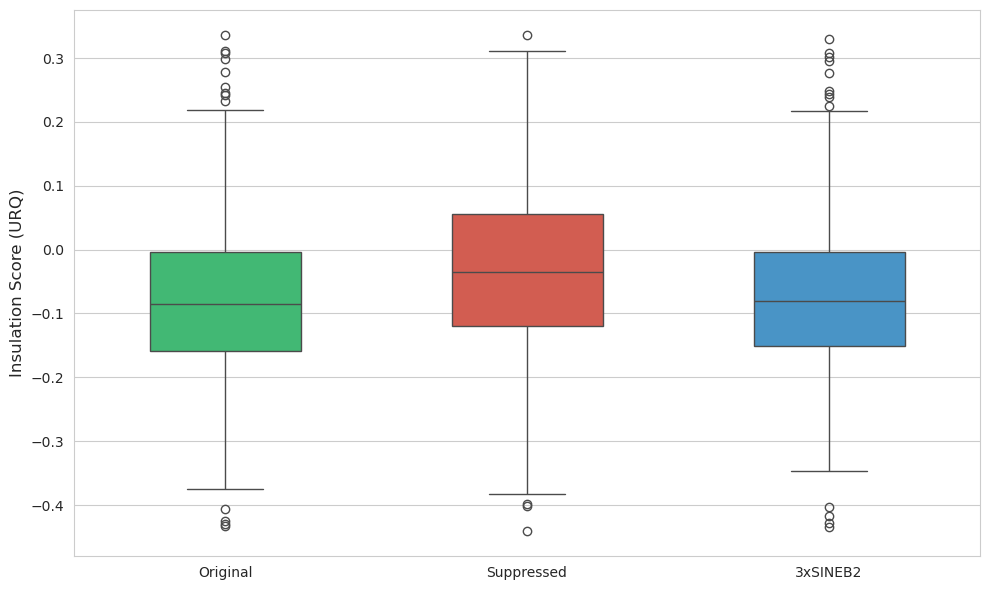

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare the data for plotting
# We select the three columns of interest and rename them for better labels
plot_df = df[['alpha_og_urq', 'alpha_ed_urq', 'alpha_sineB2']].copy()
plot_df.columns = ['Original', 'Suppressed', '3xSINEB2']

# 2. Convert to long format for Seaborn
df_long = plot_df.melt(var_name='Condition', value_name='Insulation Score (URQ)')

# 3. Create the plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create boxplot with a swarmplot overlay to see individual points
sns.boxplot(x='Condition', y='Insulation Score (URQ)', data=df_long, 
            palette=['#2ecc71', '#e74c3c', '#3498db'], width=0.5)

# 4. Add labels and horizontal line at 0 for reference
# plt.title('Alpha Genome Boundary Prediction: Effect of GC-Homopolymer Neutralization', fontsize=14)
plt.ylabel('Insulation Score (URQ)', fontsize=12)
plt.xlabel('')

# Tight layout and save
plt.tight_layout()
plt.show()

In [9]:
df.columns

Index(['chrom', 'fold', 'PearsonR', 'centered_start', 'centered_end',
       'centered_flat_start', 'centered_flat_end', 'active_fraction',
       'neutral_fraction', 'repressive_fraction', 'alpha_og_urq',
       'alpha_ed_urq', 'alpha_urq_diff', 'alpha_sineB2', 'alpha_sineB2_diff'],
      dtype='object')

In [11]:
(df["alpha_ed_urq"] - df["alpha_og_urq"]).mean()

0.042338534252439025

In [16]:
df["alpha_sineB2_diff"].mean()

0.004168552869792683

In [15]:
df["alpha_sineB2_diff"].mean() / (df["alpha_ed_urq"] - df["alpha_og_urq"]).mean()

0.09845765668074687

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [ ]:
special_idx = [58, 5, 71]

In [ ]:
# success[(success["alpha_urq_diff"] > 0.05) & (success["URQ_diff"] > 0.16)]

In [ ]:
success.iloc[71]

In [ ]:
# Assuming df and alpha_df have the same row order
x = success["URQ_diff"].values
y = success["alpha_urq_diff"].values

# Compute the shared limits
min_val = min(x.min(), y.min()) - 0.025
max_val = max(x.max(), y.max()) + 0.025

# Calculate Pearson correlation
pearson_r, p_value = pearsonr(x, y)
print(f"Pearson R = {pearson_r:.4f}, p-value = {p_value:.4e}")

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(x, y, alpha=0.6)

plt.scatter(x[special_idx], y[special_idx], color="red", s=60, label="special")

plt.xlabel("URQ diff Akita")
plt.ylabel("URQ diff Alpha Genome")
plt.title(f"Scatter plot (Pearson R = {pearson_r:.3f})")
plt.grid(True, linestyle="--", alpha=0.5)

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

# plt.savefig("ctcf_suppressing_akita_alphagenome.svg", format="svg")

plt.show()

In [ ]:
import seaborn as sns

In [ ]:
# Melt the dataframe to long format
df_melted = success.melt(value_vars=['alpha_og_urq', 'alpha_ed_urq', 'URQ_result', 'URQ_diff'],
                         var_name='Column', value_name='Value')

sns.boxplot(x="Column", y="Value", data=df_melted)
plt.title("Boxplot of Success Columns")
plt.show()